In [68]:
#importing required libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [69]:
#set up window variable
lkbk_tf = 21
#download spy data
spy_data = yf.download("SPY", start="2000-01-01")
#calculate daily return
spy_data['dr'] = spy_data['Adj Close'].pct_change()
#calculate realized volatility components
spy_data['sqrtrt'] = spy_data['dr'] ** 2
spy_data['rv+'] = spy_data['sqrtrt'].where(spy_data['dr'] > 0, 0)
spy_data['rv-'] = spy_data['sqrtrt'].where(spy_data['dr'] < 0, 0)


[*********************100%***********************]  1 of 1 completed


In [70]:
#calculate rolling sums
spy_data['rv+'] = spy_data['rv+'].rolling(window=lkbk_tf).sum()
spy_data['rv-'] = spy_data['rv-'].rolling(window=lkbk_tf).sum()
spy_data['rv'] = spy_data['rv+'] + spy_data['rv-']
#calculate rsj
spy_data['rsj'] = (spy_data['rv+'] - spy_data['rv-']) / spy_data['rv']


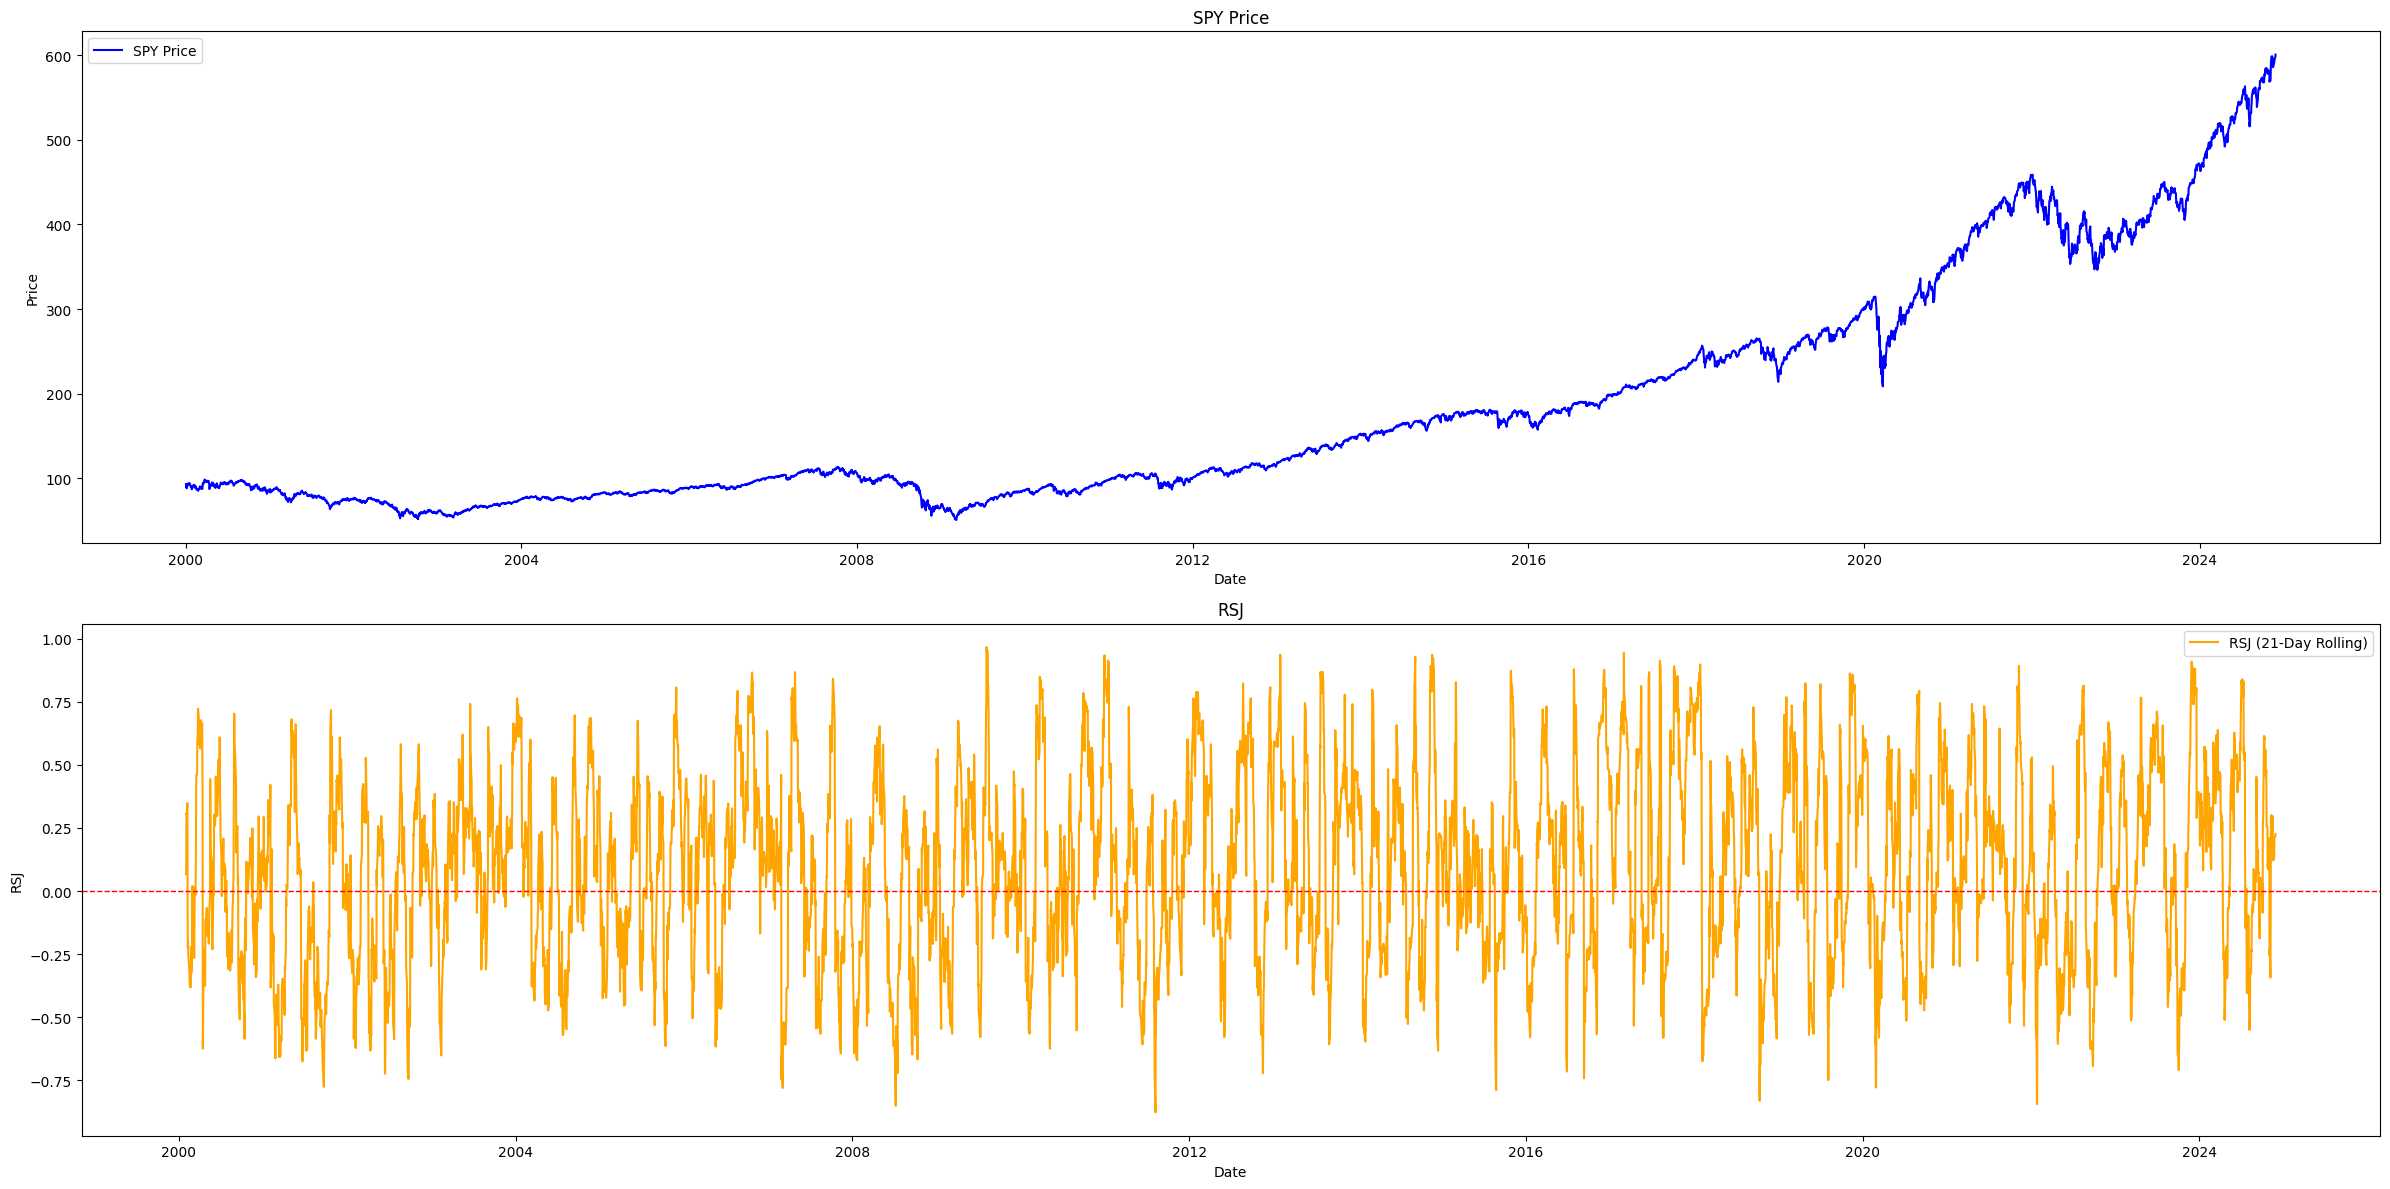

In [ ]:
#plot spy and rsj
plt.figure(figsize=(24, 12))

#plot spy price
plt.subplot(2, 1, 1)
plt.plot(spy_data['Adj Close'], label='SPY Price', color='blue')
plt.title("SPY Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

#plot rsj
lkbk_str = str(lkbk_tf)
plt.subplot(2, 1, 2)
plt.plot(spy_data['rsj'], label='RSJ  + '-Day Rolling', color='orange')
plt.title("RSJ")
plt.xlabel("Date")
plt.ylabel("RSJ")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.legend()

plt.tight_layout()
plt.show()
